# Assignment:
Clustering & Dimensionality Reduction

Dataset: Iris Dataset (sklearn.datasets.load_iris)

•Features: Sepal Length, Sepal Width, Petal Length, Petal Width

•Classes: Setosa, Versicolor, Virginica (optional for interpretation)

Instructions: Perform all tasks using Python (NumPy, pandas, scikit-learn, matplotlib/seaborn). Show all code, plots, and interpretations.



# Section A: K-Means Clustering & Elbow Method (20)

## Task 1 – K-Means & Elbow Method

1. Load the Iris dataset.

2. Apply K-Means clustering.

3. Use the Elbow Method to determine the optimal number of clusters.

4. Plot clusters in 2D (first two features) or 3D (first three features).

## 1. Load the dataset and explore

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris()

print(iris.keys())

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df["species"] = df["species"].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
df.shape

(150, 5)

In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Apply K-Means clustering.

In [ ]:
X = df.drop("species", axis=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_scaled)

clusters = kmeans.labels_

df["cluster"] = clusters



K-Means successfully grouped the Iris flowers into three distinct clusters. The Setosa flowers formed a clearly separated cluster, while Versicolor and Virginica showed some overlap, which is expected because their feature measurements are more similar.

## 3. Elbow Method

In [ ]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

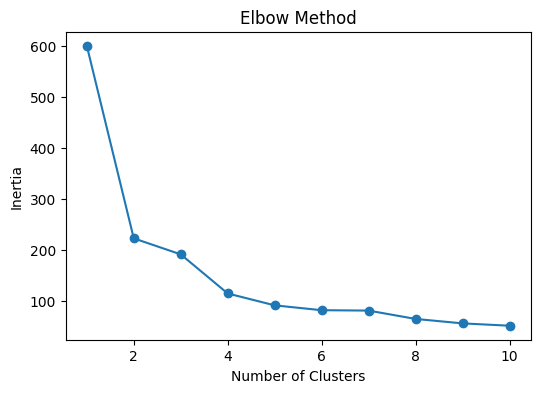

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

The Elbow Method was used to determine the optimal number of clusters by plotting inertia against different values of K. The curve showed a noticeable bend around K = 3, indicating that three clusters provide the best balance between minimizing clustering error and avoiding unnecessary complexity.

## 4. Plot clusters in 2D (first two features) or 3D (first three features).

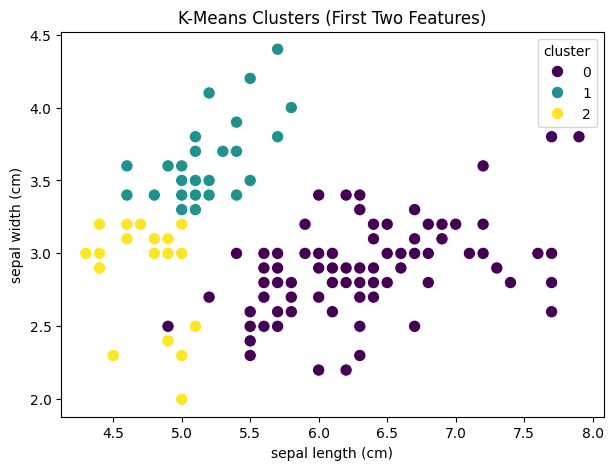

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df["cluster"],
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters (First Two Features)")

plt.xlabel(iris.feature_names[0])

plt.ylabel(iris.feature_names[1])

plt.show()

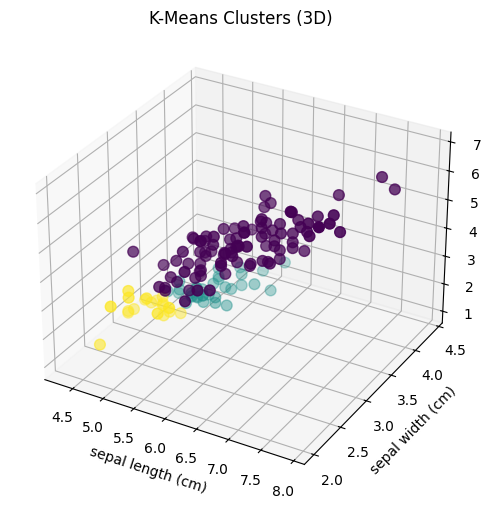

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    df.iloc[:,2],
    c=df["cluster"],
    cmap="viridis",
    s=60
)

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])

plt.title("K-Means Clusters (3D)")

plt.show()

# Section B: Principal Component Analysis (PCA) (25)

## Task 2 – PCA & Visualization

1. Apply PCA on the Iris dataset to reduce it to 2 dimensions.

2. Plot the first two principal components.

3. Show explained variance ratio.

4. Compare clustering results on PCA-reduced data vs original data.


## 1. Apply PCA on the Iris dataset to reduce it to 2 dimensions.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["species"] = df["species"]



## 2 . Plot the First Two Principal Components

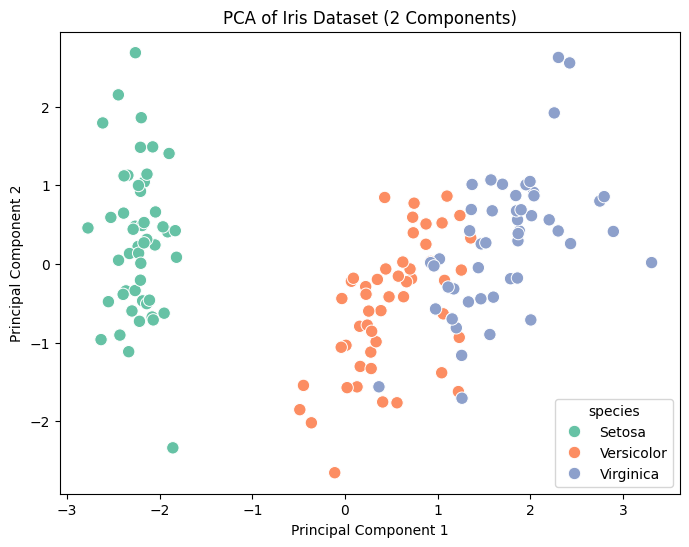

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    palette="Set2",
    s=80
)

plt.title("PCA of Iris Dataset (2 Components)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

## 3. Show explained variance ratio.



In [ ]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [ ]:
print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()*100
)

Total Explained Variance: 95.81320720000166


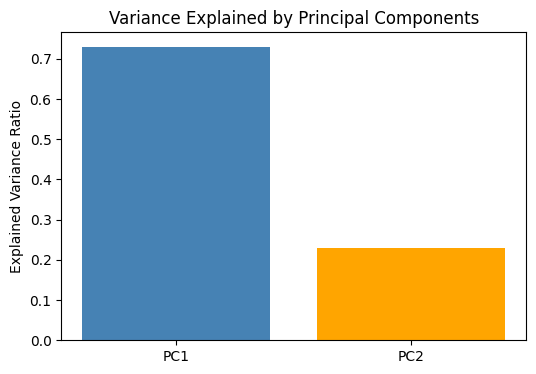

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    ["PC1","PC2"],
    pca.explained_variance_ratio_,
    color=["steelblue","orange"]
)

plt.ylabel("Explained Variance Ratio")

plt.title("Variance Explained by Principal Components")

plt.show()

## 4. Compare clustering results on PCA-reduced data vs original data.



In [ ]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

pca_clusters = kmeans_pca.fit_predict(X_pca)

pca_df["cluster"] = pca_clusters



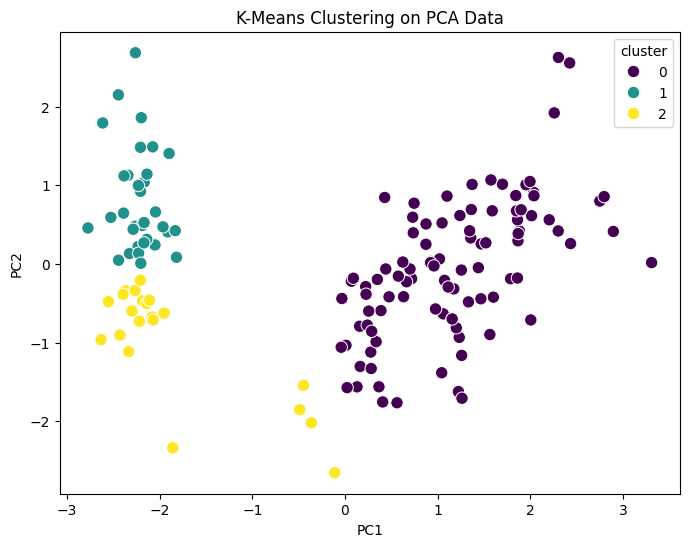

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Clustering on PCA Data")

plt.show()

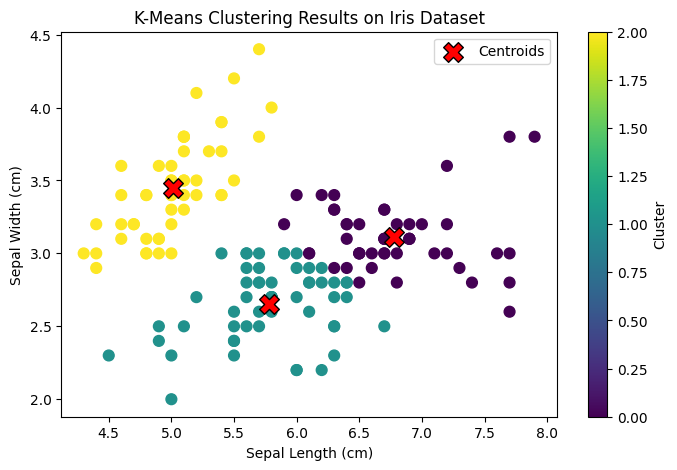

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X = iris.data[:, :2]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


centroids = scaler.inverse_transform(kmeans.cluster_centers_)


plt.figure(figsize=(8,5))

scatter = plt.scatter(
    X[:,0], X[:,1],
    c=clusters,
    cmap="viridis",
    s=60
)


plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=200,
    edgecolors="black",
    label="Centroids"
)


plt.title("K-Means Clustering Results on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()


cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.show()

In [ ]:
import pandas as pd
import time
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


iris = load_iris()
X = iris.data


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


start = time.perf_counter()
kmeans_original = KMeans(n_clusters=3, random_state=42)
labels_original = kmeans_original.fit_predict(X_scaled)
original_time = time.perf_counter() - start


start = time.perf_counter()
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
pca_time = time.perf_counter() - start


sil_original = silhouette_score(X_scaled, labels_original)
sil_pca = silhouette_score(X_pca, labels_pca)


comparison_df = pd.DataFrame({
    "Aspect": [
        "Dimensions",
        "Information Retained",
        "Silhouette Score",
        "Training Time (seconds)"
    ],
    "Original Data": [
        X_scaled.shape[1],
        "100%",
        round(sil_original, 3),
        round(original_time, 6)
    ],
    "PCA Data": [
        X_pca.shape[1],
        f"{pca.explained_variance_ratio_.sum()*100:.2f}%",
        round(sil_pca, 3),
        round(pca_time, 6)
    ]
})

comparison_df

,Aspect,Original Data,PCA Data
0,Dimensions,4,2
1,Information Retained,100%,95.81%
2,Silhouette Score,0.48,0.523
3,Training Time (seconds),0.002437,0.002118




- Original dimensions: 4
- PCA dimensions: 2
- Information retained: 95.81%
- Silhouette Score improved: 0.480 → 0.523
- Training time reduced: 0.002437s → 0.002118s
- PCA provided better cluster separation and faster computation while maintaining almost all of the dataset's information.

#Section C: Hierarchical Clustering (25)

## Task 3 – Hierarchical Clustering & Dendrogram

1. Apply Hierarchical Clustering on the Iris dataset.

2. Draw a dendrogram.

3. Compare clusters with K-Means results.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
X = iris.data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
linked = linkage(
    X_scaled,
    method="ward"
)

## 1. Apply Hierarchical Clustering on the Iris dataset.

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hier_clusters = hierarchical.fit_predict(X_scaled)

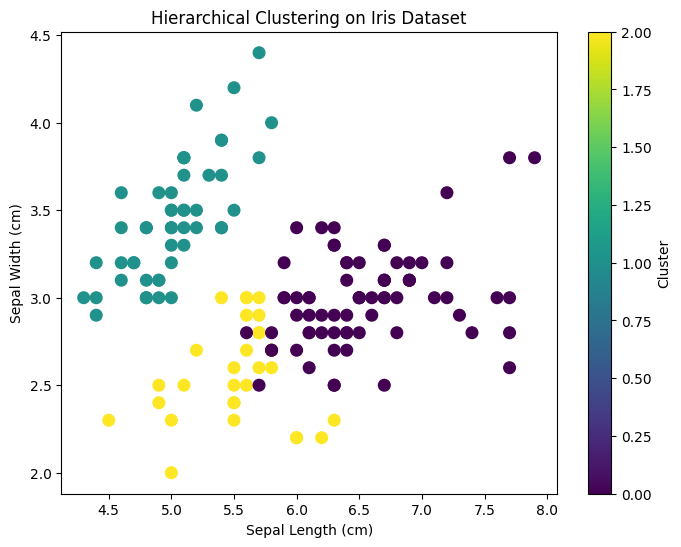

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=hier_clusters,
    cmap="viridis",
    s=70
)

plt.title("Hierarchical Clustering on Iris Dataset")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.colorbar(label="Cluster")

plt.show()

##2. Draw a dendrogram.



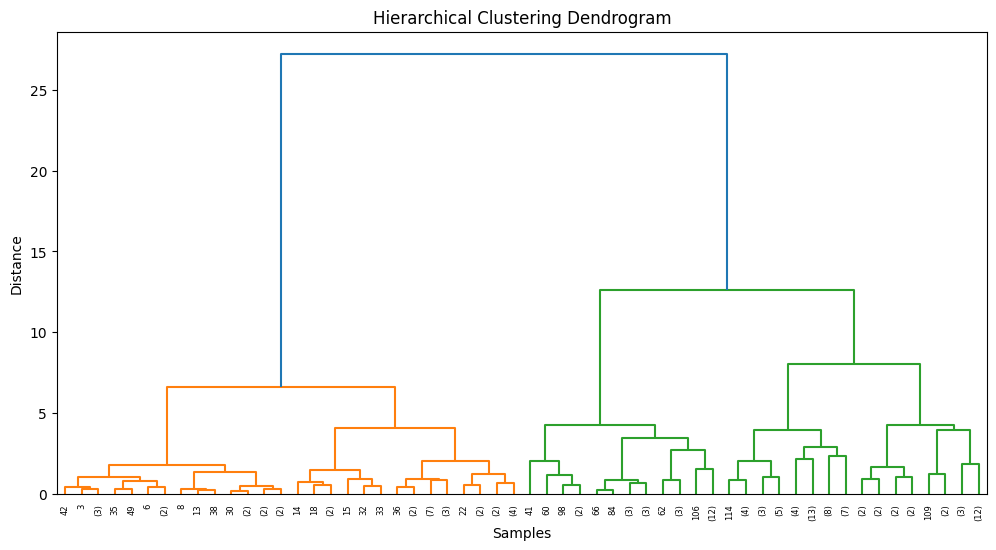

In [ ]:
plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Samples")

plt.ylabel("Distance")

plt.show()

## 3. Compare clusters with K-Means results.



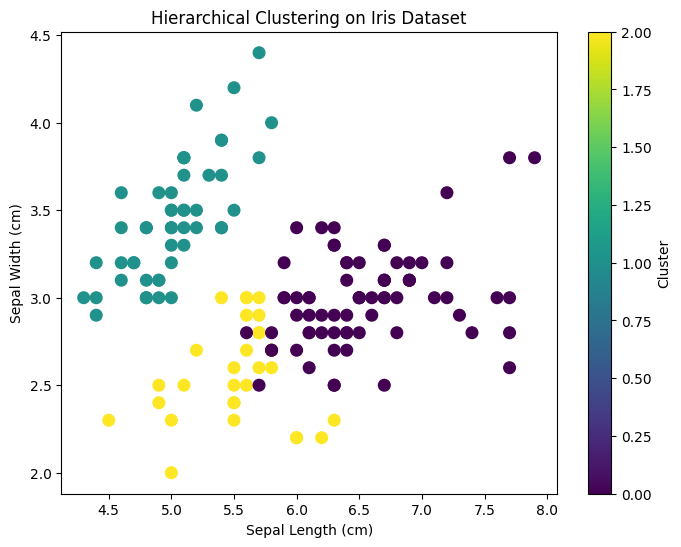


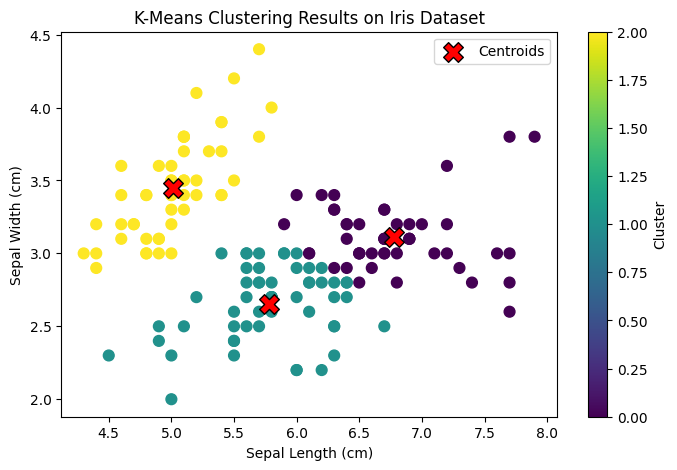

### Numerical Comparison

- compare using the Silhouette Score.

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, clusters)

hier_score = silhouette_score(X_scaled, hier_clusters)

print("K-Means Silhouette Score:", round(kmeans_score,3))
print("Hierarchical Silhouette Score:", round(hier_score,3))

K-Means Silhouette Score: 0.445
Hierarchical Silhouette Score: 0.447


## Comparison Table: K-Means vs Hierarchical Clustering

| **Aspect** | **K-Means** | **Hierarchical** |
|------------|-------------|------------------|
| Need K beforehand | Yes | No (Dendrogram helps) |
| Cluster Method | Centroids | Tree merging |
| Speed | Faster | Slower |
| Dendrogram | No | Yes |
| Best for | Large datasets | Small/Medium datasets |
| Iris Performance | Very Good | Very Good |

# Section D: DBSCAN (25)

## Task 4 – DBSCAN Clustering

1. Apply DBSCAN on the Iris dataset.

2. Experiment with different values of eps and min_samples.

3. Plot clusters with noise points highlighted.

4. Compare DBSCAN clusters with K-Means clusters.

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 1. Apply DBSCAN on the Iris dataset.

In [ ]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

In [ ]:
print("Cluster Labels:")
print(db_clusters)

print("Unique Labels:", set(db_clusters))

Cluster Labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]
Unique Labels: {np.int64(0), np.int64(1), np.int64(-1)}


In [ ]:
# Count Points in Each Cluster

import pandas as pd

cluster_counts = pd.Series(db_clusters).value_counts().sort_index()

print(cluster_counts)

-1    34
 0    45
 1    71
Name: count, dtype: int64


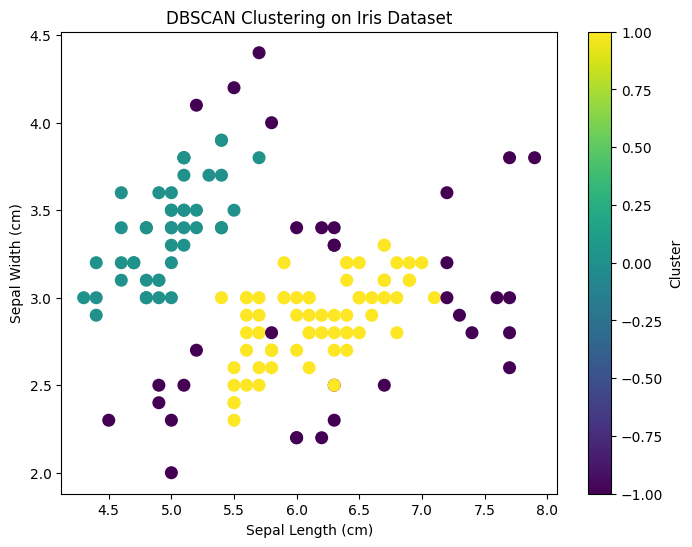

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X[:,0],
    X[:,1],
    c=db_clusters,
    cmap="viridis",
    s=70
)

plt.title("DBSCAN Clustering on Iris Dataset")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.colorbar(scatter, label="Cluster")

plt.show()

## 2. Experiment with different values of eps and min_samples:

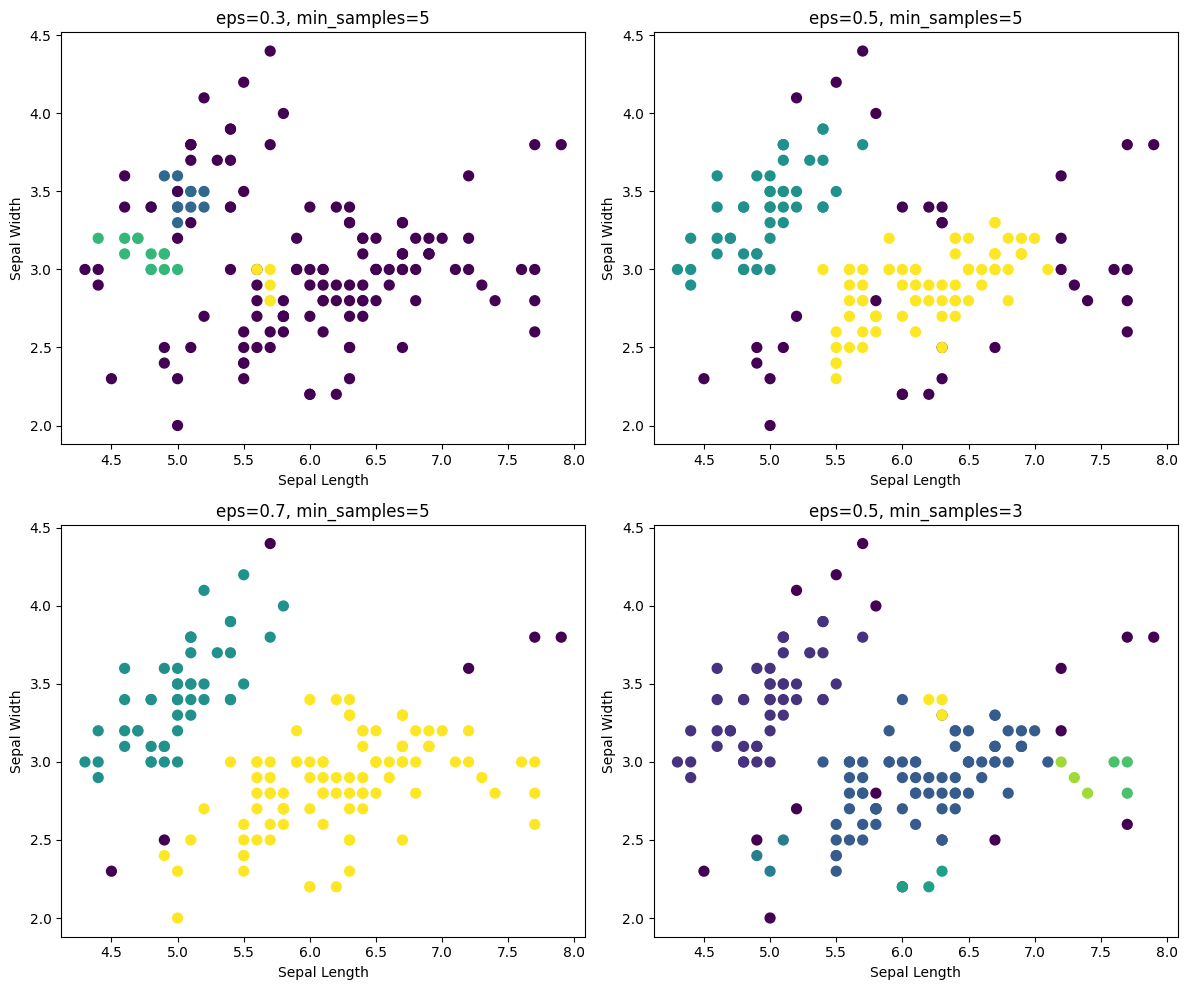

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

parameters = [
    (0.3,5),
    (0.5,5),
    (0.7,5),
    (0.5,3)
]

plt.figure(figsize=(12,10))

for i,(eps,min_samples) in enumerate(parameters):

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = db.fit_predict(X_scaled)

    plt.subplot(2,2,i+1)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis",
        s=50
    )

    plt.title(f"eps={eps}, min_samples={min_samples}")

    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")

plt.tight_layout()
plt.show()

## 3. Plot clusters with noise points highlighted.

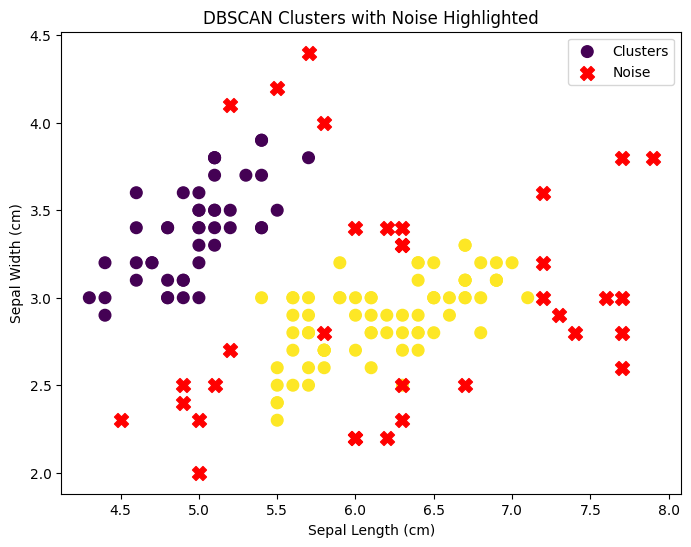

In [ ]:
plt.figure(figsize=(8,6))


plt.scatter(
    X[db_clusters != -1,0],
    X[db_clusters != -1,1],
    c=db_clusters[db_clusters != -1],
    cmap="viridis",
    s=70,
    label="Clusters"
)


plt.scatter(
    X[db_clusters == -1,0],
    X[db_clusters == -1,1],
    color="red",
    s=100,
    marker="X",
    label="Noise"
)

plt.title("DBSCAN Clusters with Noise Highlighted")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.legend()

plt.show()

## 4. Compare DBSCAN with K-Means

##K-Means

- Requires K=3

- Every point belongs to a cluster.

## DBSCAN

- No need for K

- Detects noise automatically.

### Numerical Comparison

- compare using the Silhouette Score.

In [ ]:
from sklearn.metrics import silhouette_score


kmeans_score = silhouette_score(X_scaled, clusters)


mask = db_clusters != -1

dbscan_score = silhouette_score(
    X_scaled[mask],
    db_clusters[mask]
)

print("K-Means:", round(kmeans_score,3))
print("DBSCAN:", round(dbscan_score,3))

K-Means: 0.445
DBSCAN: 0.656


## Comparison Table: K-Means vs DBSCAN

| **Aspect** | **K-Means** | **DBSCAN** |
|------------|-------------|------------|
| Need K beforehand | Yes | No |
| Detects Noise | No | Yes |
| Cluster Shape | Mostly Circular | Arbitrary Shapes |
| Outlier Handling | Poor | Excellent |
| Speed | Faster | Moderate |
| Iris Performance | Very Good | Very Good |